In [6]:
import pandas as pd
from openai import OpenAI
df = pd.read_csv("/Users/aryamane/Downloads/safety1_data.csv")
client = OpenAI(api_key="", base_url="https://api.deepseek.com")



In [7]:
print(df['Final Narrative'].head())

0    An employee was resetting the chain at the cor...
1    An employee was closing an office door when th...
2    An employee was rotating a carbide granulator ...
3    An employee was using a CNC metal lathe machin...
4    An employee was operating a band saw when his ...
Name: Final Narrative, dtype: object


In [10]:
df['Final Narrative'] = df['Final Narrative'].apply(lambda x: str(x))


In [12]:
print(df['Final Narrative'].dtype)

object


In [43]:
def extract_keywords_from_text(text):
    if not text.strip():
        print("Error: Input text is empty!")
        return None

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Extract key keywords from this text."},
                {"role": "user", "content": text}
            ],
            stream=False
        )

        if response.choices and len(response.choices) > 0:
            keywords = response.choices[0].message.content
            print("Extracted Keywords:", keywords)  # Debug print
            return keywords
        else:
            print("Error: No response from API!")
            return None

    except Exception as e:
        print("API Error:", e)
        return None


In [45]:
df.loc[:499, 'extracted_keywords'] = df.loc[:499, 'Final Narrative'].apply(extract_keywords_from_text)


Extracted Keywords: Here are the key keywords extracted from the text:  

- **Employee**  
- **Resetting**  
- **Chain**  
- **Core station**  
- **Foot pedal**  
- **Hoist**  
- **Amputation**  
- **Left index finger**  
- **Ring finger**  

These keywords summarize the main elements of the incident. Let me know if you'd like any refinements!
Extracted Keywords: Here are the key keywords extracted from the text:  

- **Employee**  
- **Closing**  
- **Office door**  
- **Middle fingertip**  
- **Caught**  
- **Door frame**  
- **Fingertip amputation**  

These keywords summarize the incident involving a workplace injury. Let me know if you need further refinement!
Extracted Keywords: Here are the key keywords extracted from the text:  

- **Employee**  
- **Carbide granulator blade**  
- **Rotating**  
- **Finger caught**  
- **Stationary part**  
- **Machine**  
- **Right middle finger**  
- **Partially amputated**  
- **Avulsion**  
- **Right ring fingertip**  

These keywords summa

In [83]:
df['extracted_keywords'] = df['extracted_keywords'].str.replace(
    "Here are the key keywords extracted from the text", " ", regex=False
).str.strip()


In [85]:
print(df[['Final Narrative', 'extracted_keywords']].head())

                                     Final Narrative  \
0  An employee was resetting the chain at the cor...   
1  An employee was closing an office door when th...   
2  An employee was rotating a carbide granulator ...   
3  An employee was using a CNC metal lathe machin...   
4  An employee was operating a band saw when his ...   

                                  extracted_keywords  
0  :  \n\n- **Employee**  \n- **Resetting**  \n- ...  
1  :  \n\n- **Employee**  \n- **Closing**  \n- **...  
2  :  \n\n- **Employee**  \n- **Carbide granulato...  
3  :  \n\n- **Employee**  \n- **CNC metal lathe m...  
4  Key keywords from the text:  \n\n- **Employee*...  


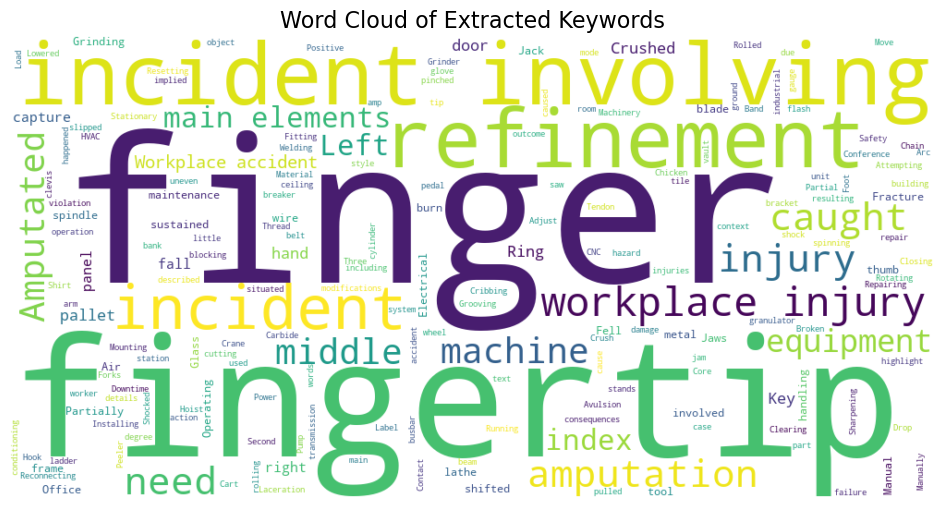

In [87]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Convert cleaned extracted keywords into a single string
all_keywords = " ".join(df['extracted_keywords'].dropna())
test= all_keywords.replace("keywords"," ").replace("summarize",'').replace('employee',' ').replace("Employee",' ').replace('know',' ').replace("Let",' ').replace("Right"," ")
# Generate the word cloud
wordcloud = WordCloud(
    width=1000, height=500, background_color="white", colormap="viridis"
).generate(test)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.title("Word Cloud of Extracted Keywords", fontsize=16)
plt.show()